#### Tesla Deliveries & Production Forecasting

#### Objective
Build an end-to-end Machine Learning pipeline using Tesla's Deliveries and Production dataset (2015–2025).

#### Tasks
- Data Collection
- Data Preprocessing
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Regression Modeling
- Hyperparameter Tuning
- Time Series Forecasting
- Model Evaluation

Import Libraries

In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

Step 1: Load Dataset

Read the Tesla Deliveries and Production dataset and inspect its structure.

In [3]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [4]:
print("Shape:", df.shape)

df.info()

Shape: (2640, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [5]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


Step 2: Data Cleaning

Check for:
- Missing values
- Duplicate records
- Remove duplicates

In [7]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.drop_duplicates(inplace=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (2640, 12)


Step 3: Exploratory Data Analysis (EDA)

Analyze trends and relationships within the dataset.

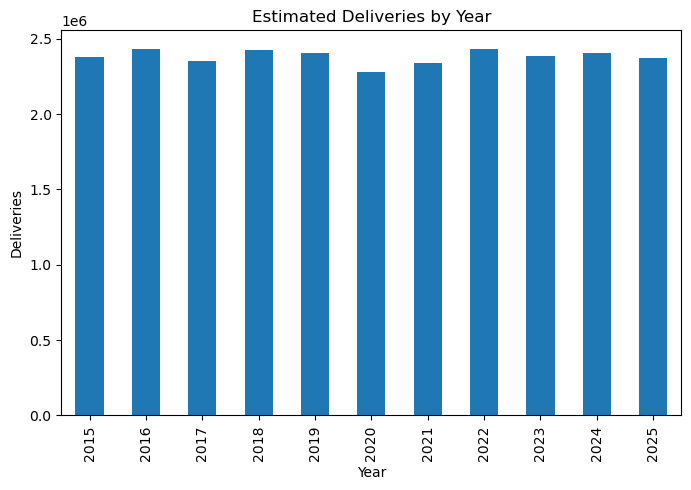

In [13]:
yearly_deliveries = df.groupby("Year")["Estimated_Deliveries"].sum()

plt.figure(figsize=(8,5))
yearly_deliveries.plot(kind="bar")

plt.title("Estimated Deliveries by Year")
plt.ylabel("Deliveries")

plt.show()

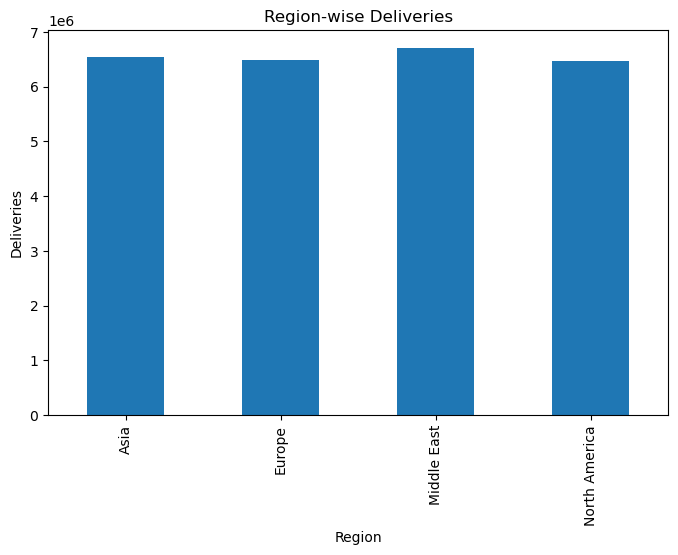

In [14]:
region_deliveries = df.groupby("Region")["Estimated_Deliveries"].sum()

plt.figure(figsize=(8,5))
region_deliveries.plot(kind="bar")

plt.title("Region-wise Deliveries")
plt.ylabel("Deliveries")

plt.show()

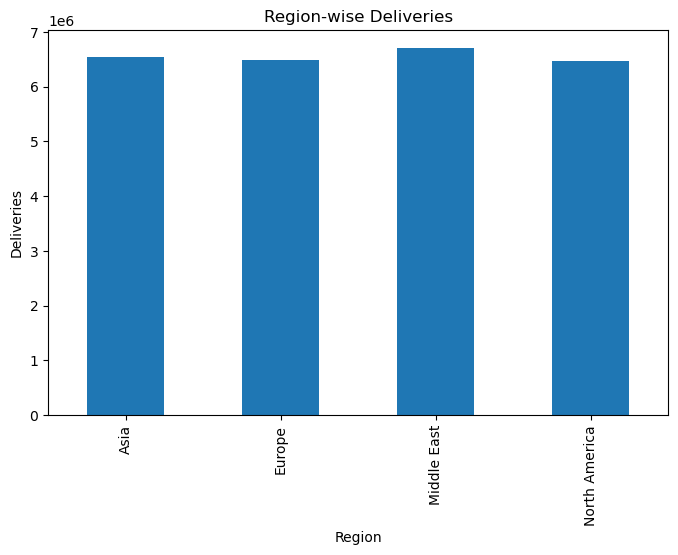

In [15]:
region_deliveries = df.groupby("Region")["Estimated_Deliveries"].sum()

plt.figure(figsize=(8,5))
region_deliveries.plot(kind="bar")

plt.title("Region-wise Deliveries")
plt.ylabel("Deliveries")

plt.show()

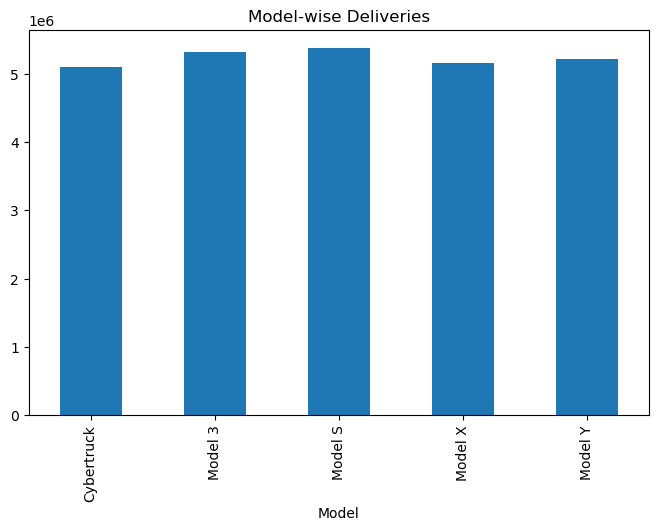

In [16]:
model_sales = df.groupby("Model")["Estimated_Deliveries"].sum()

plt.figure(figsize=(8,5))
model_sales.plot(kind="bar")

plt.title("Model-wise Deliveries")

plt.show()

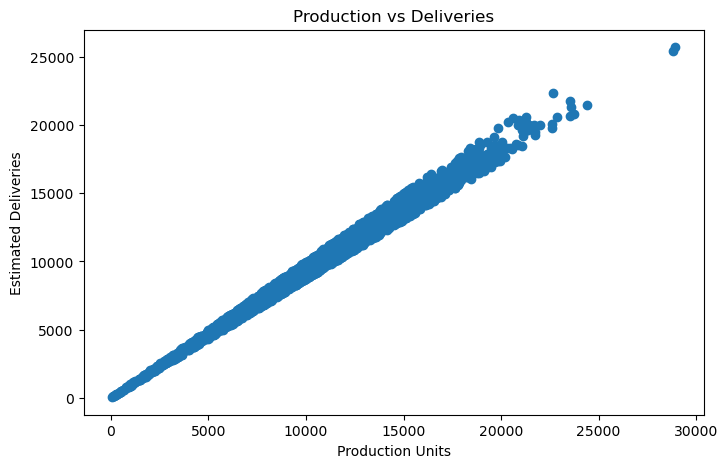

In [17]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Production_Units"],
    df["Estimated_Deliveries"]
)

plt.xlabel("Production Units")
plt.ylabel("Estimated Deliveries")

plt.title("Production vs Deliveries")

plt.show()

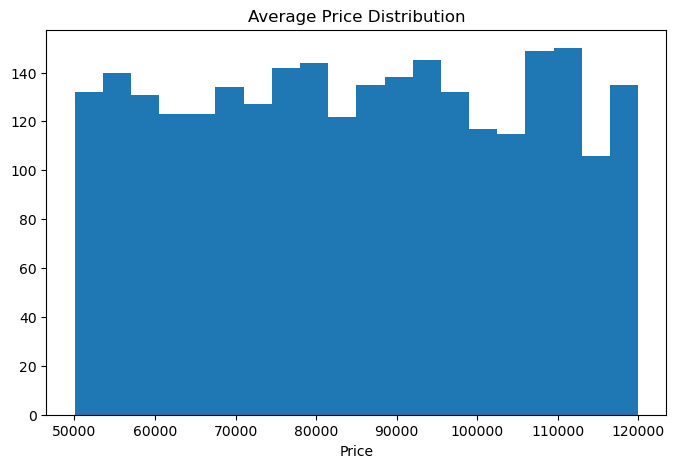

In [18]:
plt.figure(figsize=(8,5))

plt.hist(df["Avg_Price_USD"], bins=20)

plt.title("Average Price Distribution")

plt.xlabel("Price")

plt.show()

In [19]:
corr = df.select_dtypes(include=np.number).corr()

corr

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
Year,1.000000e+00,2.216119e-15,-0.002863,-0.002761,-0.004991,-0.030486,-0.029128,-0.019244,-0.003466
Month,2.216119e-15,1.000000e+00,0.030877,0.028971,0.024857,0.001714,0.002143,0.032920,-0.011325
Estimated_Deliveries,-2.863112e-03,3.087690e-02,1.000000,0.994234,-0.027546,-0.007765,-0.006606,0.836814,0.000753
Production_Units,-2.760884e-03,2.897149e-02,0.994234,1.000000,-0.029263,-0.004139,-0.002885,0.833770,0.000600
Avg_Price_USD,-4.990980e-03,2.485676e-02,-0.027546,-0.029263,1.000000,-0.018203,-0.017854,-0.028523,-0.017790
Battery_Capacity_kWh,-3.048584e-02,1.714479e-03,-0.007765,-0.004139,-0.018203,1.000000,0.994313,0.498071,-0.005834
Range_km,-2.912765e-02,2.142889e-03,-0.006606,-0.002885,-0.017854,0.994313,1.000000,0.501698,-0.008291
CO2_Saved_tons,-1.924402e-02,3.291988e-02,0.836814,0.833770,-0.028523,0.498071,0.501698,1.000000,-0.007517
Charging_Stations,-3.465622e-03,-1.132526e-02,0.000753,0.000600,-0.017790,-0.005834,-0.008291,-0.007517,1.000000


 Step 4: Feature Engineering
 
Create additional useful features.

In [20]:
df["Quarter"] = ((df["Month"] - 1) // 3) + 1

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Quarter
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,1
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,1
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,1
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,4


In [21]:
df["Year_Month"] = (
    df["Year"].astype(str)
    + "_"
    + df["Month"].astype(str)
)

Step 5: Define Features and Target Variable

Target Variable = Estimated_Deliveries

In [22]:
y = df["Estimated_Deliveries"]

In [23]:
X = df.drop(
    columns=["Estimated_Deliveries"]
)

In [24]:
numerical_features = [
    "Year",
    "Month",
    "Production_Units",
    "Avg_Price_USD",
    "Battery_Capacity_kWh",
    "Range_km",
    "CO2_Saved_tons",
    "Charging_Stations",
    "Quarter"
]

In [25]:
categorical_features = [
    "Region",
    "Model",
    "Source_Type",
    "Year_Month"
]

Step 6: Preprocessing pipeline
Apply:
- Missing Value Imputation
- Feature Scaling
- One-Hot Encoding

In [26]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [27]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

In [28]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Step 7: Linear Regression Model

Build a baseline model.

In [30]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Year', 'Month',
                                                   'Production_Units',
                                                   'Avg_Price_USD',
                                                   'Battery_Capacity_kWh',
                                                   'Range_km', 'CO2_Saved_tons',
                                                   'Charging_Stations',
                                                   'Quarter']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Region', 'Model',
                                                   'Source_Type',
                                                   'Year_Month'])])),
                ('model', LinearRegression())])

In [31]:
lr_pred = lr_pipeline.predict(X_test)

In [32]:
print("MAE:",
      mean_absolute_error(y_test, lr_pred))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, lr_pred)))

print("R2 Score:",
      r2_score(y_test, lr_pred))

MAE: 321.57611125471686
RMSE: 395.5443783706022
R2 Score: 0.9895040701041079


Step 8: Random Forest Regression

Train an advanced ensemble model.

In [33]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model",
     RandomForestRegressor(
         random_state=42
     ))
])

rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Year', 'Month',
                                                   'Production_Units',
                                                   'Avg_Price_USD',
                                                   'Battery_Capacity_kWh',
                                                   'Range_km', 'CO2_Saved_tons',
                                                   'Charging_Stations',
                                                   'Quarter']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Region', 'Model',
                                                   'Source_Type',
                                                   'Year_Month'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [34]:
rf_pred = rf_pipeline.predict(X_test)

In [35]:
print("MAE:",
      mean_absolute_error(y_test, rf_pred))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, rf_pred)))

print("R2 Score:",
      r2_score(y_test, rf_pred))

MAE: 323.94162878787876
RMSE: 409.70027689042496
R2 Score: 0.988739361846682


Step 9: Hyperparameter Tuning

Optimize Random Forest performance using GridSearchCV.

In [36]:
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [5, 10, 15, None]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Year',
                                                                          'Month',
                                                                          'Production_Units',
                                                                          'Avg_Price_USD',
                                                                          'Battery_Capacity_kWh',
                                                                          'Range_km',
                                                                          'CO2_Saved_tons',
                                                                          'Charging_Stations',
                                                                          'Quarter']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['Region',
                                                                          'Model',
                                                                          'Source_Type',
                                                                          'Year_Month'])])),
                                       ('model',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [5, 10, 15, None],
                         'model__n_estimators': [100, 200, 300]},
             scoring='r2')

In [37]:
grid_search.best_params_

{'model__max_depth': 15, 'model__n_estimators': 200}

In [38]:
best_model = grid_search.best_estimator_

In [39]:
final_pred = best_model.predict(X_test)

In [40]:
print("MAE:",
      mean_absolute_error(y_test, final_pred))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, final_pred)))

print("R2 Score:",
      r2_score(y_test, final_pred))

MAE: 324.55968606409465
RMSE: 411.43974939761387
R2 Score: 0.988643539836034


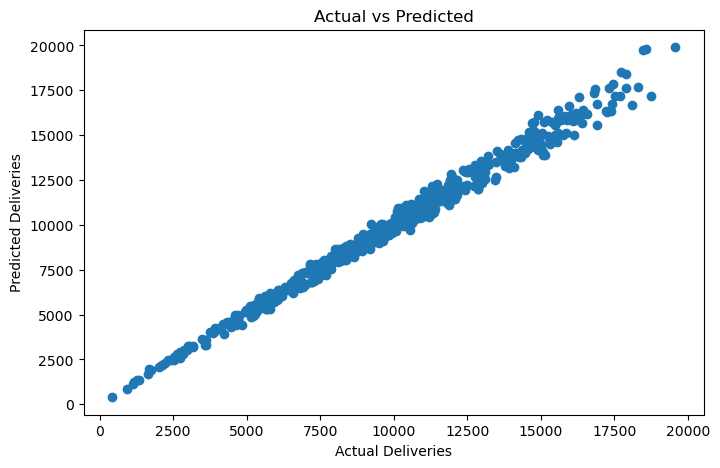

In [50]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    final_pred
)

plt.xlabel("Actual Deliveries")
plt.ylabel("Predicted Deliveries")

plt.title("Actual vs Predicted")

plt.show()

Step 11: Time Series Forecasting using ARIMA

Forecast future Tesla deliveries using historical delivery data.

In [54]:
df["Date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" +
    df["Month"].astype(str) + "-01"
)

df = df.sort_values("Date")

In [55]:
ts_df = (
    df.groupby("Date")["Estimated_Deliveries"]
      .sum()
      .reset_index()
)

ts_df.set_index("Date", inplace=True)

ts_df.head()

,Estimated_Deliveries
Date,
2015-01-01,183180
2015-02-01,165053
2015-03-01,184567
2015-04-01,225623
2015-05-01,184264


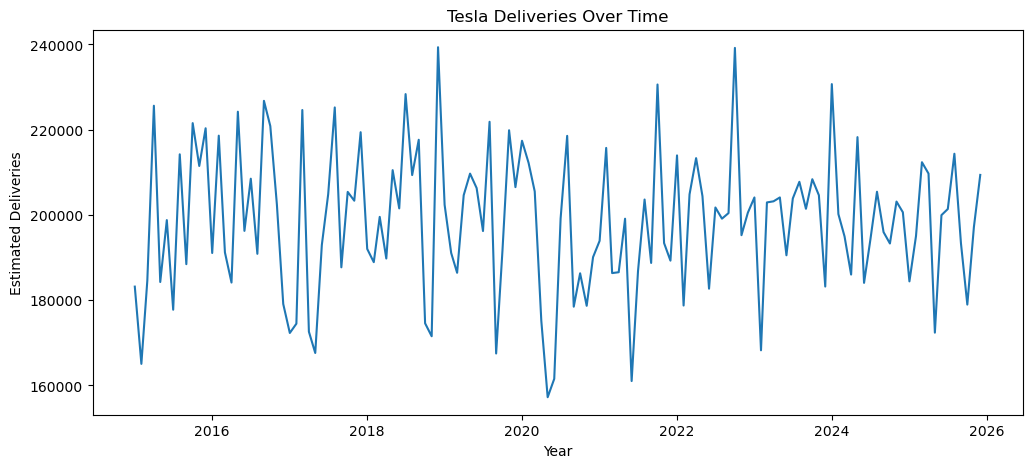

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    forecast_df.index,
    forecast_df["Estimated_Deliveries"]
)

plt.title("Tesla Deliveries Over Time")
plt.xlabel("Year")
plt.ylabel("Estimated Deliveries")

plt.show()

Forecasting using Rolling mean(eda) and ARIMA

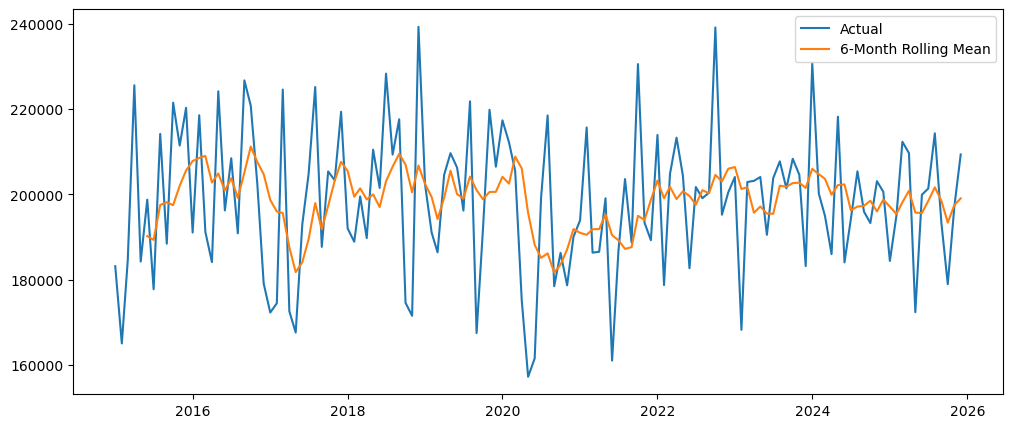

In [65]:
ts_df["Rolling_Mean"] = (
    ts_df["Estimated_Deliveries"]
    .rolling(window=6)
    .mean()
)

plt.figure(figsize=(12,5))
plt.plot(ts_df["Estimated_Deliveries"], label="Actual")
plt.plot(ts_df["Rolling_Mean"], label="6-Month Rolling Mean")
plt.legend()
plt.show()

In [66]:
train_size = int(len(ts_df) * 0.8)

train = ts_df.iloc[:train_size]
test = ts_df.iloc[train_size:]

In [67]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(
    train["Estimated_Deliveries"],
    order=(1,1,1)
)

arima_fit = arima_model.fit()

print(arima_fit.summary())

                                SARIMAX Results                                 
Dep. Variable:     Estimated_Deliveries   No. Observations:                  105
Model:                   ARIMA(1, 1, 1)   Log Likelihood               -1187.499
Date:                  Sat, 06 Jun 2026   AIC                           2380.998
Time:                          23:13:44   BIC                           2388.931
Sample:                      01-01-2015   HQIC                          2384.211
                           - 09-01-2023                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1574      0.100      1.580      0.114      -0.038       0.353
ma.L1         -0.6499      0.083     -7.823      0.000      -0.813      -0.487
sigma2      4.024e+08   3.74e-11   1

In [60]:
forecast = arima_fit.forecast(
    steps=len(test)
)

In [61]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

mae = mean_absolute_error(
    test["Estimated_Deliveries"],
    forecast
)

rmse = np.sqrt(
    mean_squared_error(
        test["Estimated_Deliveries"],
        forecast
    )
)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 10178.06412039386
RMSE: 12967.818296833782


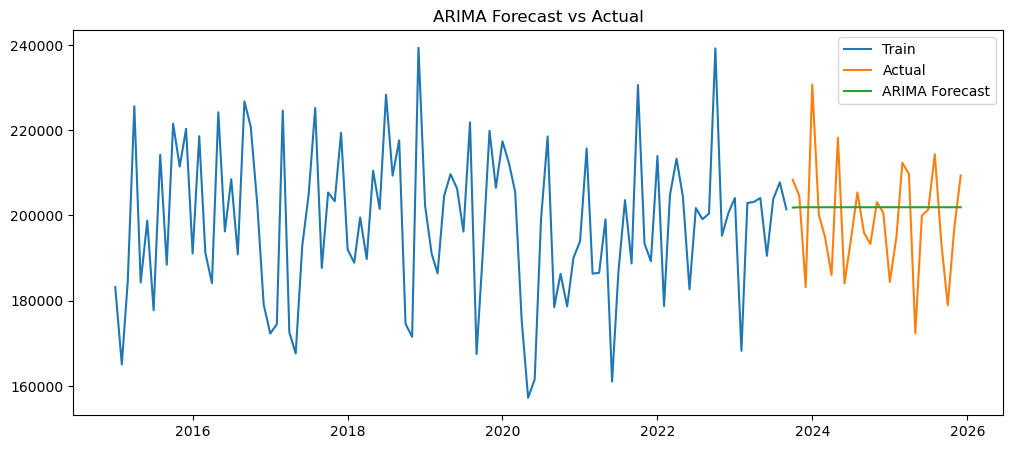

In [62]:
plt.figure(figsize=(12,5))

plt.plot(
    train.index,
    train["Estimated_Deliveries"],
    label="Train"
)

plt.plot(
    test.index,
    test["Estimated_Deliveries"],
    label="Actual"
)

plt.plot(
    test.index,
    forecast,
    label="ARIMA Forecast"
)

plt.legend()
plt.title("ARIMA Forecast vs Actual")
plt.show()

In [63]:
final_model = ARIMA(
    ts_df["Estimated_Deliveries"],
    order=(1,1,1)
).fit()

future_forecast = final_model.forecast(steps=12)

print(future_forecast)

2026-01-01    201130.711311
2026-02-01    199815.368233
2026-03-01    199605.917029
2026-04-01    199572.564660
2026-05-01    199567.253731
2026-06-01    199566.408035
2026-07-01    199566.273369
2026-08-01    199566.251925
2026-09-01    199566.248511
2026-10-01    199566.247967
2026-11-01    199566.247880
2026-12-01    199566.247867
Freq: MS, Name: predicted_mean, dtype: float64


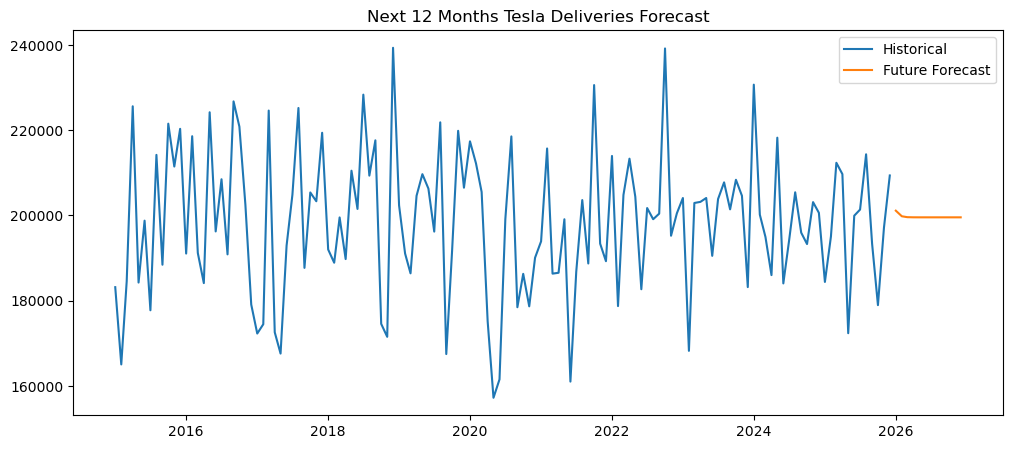

In [64]:
future_dates = pd.date_range(
    start=ts_df.index.max() + pd.DateOffset(months=1),
    periods=12,
    freq="MS"
)

plt.figure(figsize=(12,5))

plt.plot(
    ts_df.index,
    ts_df["Estimated_Deliveries"],
    label="Historical"
)

plt.plot(
    future_dates,
    future_forecast,
    label="Future Forecast"
)

plt.legend()
plt.title("Next 12 Months Tesla Deliveries Forecast")
plt.show()

Step 12: Key Insights

Findings

1. Tesla deliveries fluctuated significantly in the historical data.
2. ARIMA forecasts deliveries to remain stable at around 200,000 units/month over the next year.
3. No strong upward or downward trend is observed in the forecast.
4. The model suggests consistent future demand and production planning opportunities.
5. Forecast values tend toward the historical average, indicating market stability.

Conclusion

Tesla deliveries fluctuated significantly in the historical data.
ARIMA forecasts deliveries to remain stable at around 200,000 units/month over the next year.
The model suggests consistent future demand and production planning opportunities.
Forecast values tend toward the historical average, indicating market stability.

#### Business Impact
The model helps estimate future vehicle deliveries and production trends, enabling better production planning, inventory management, and strategic decision-making.